<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/Unsupervised_Topic_Modeling_of_BBC_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Topic Modeling of BBC News

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

#Dataset

In [4]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('learn-ai-bbc')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/learn-ai-bbc


In [5]:
print(os.listdir(path))

['BBC News Test.csv', 'BBC News Train.csv', 'BBC News Sample Solution.csv']


In [6]:
df = pd.read_csv(os.path.join(path, 'BBC News Train.csv'))

In [7]:
df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [8]:
df.shape

(1490, 3)

In [9]:
df.columns

Index(['ArticleId', 'Text', 'Category'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB


In [11]:
df["Category"].value_counts()

,count
Category,
sport,346
business,336
politics,274
entertainment,273
tech,261


#Basic EDA

In [12]:
df["text_length"] = df["Text"].str.len()
df["word_count"] = df["Text"].str.split().str.len()

df.head()

,ArticleId,Text,Category,text_length,word_count
0,1833,worldcom ex-boss launches defence lawyers defe...,business,1866,301
1,154,german business confidence slides german busin...,business,2016,325
2,1101,bbc poll indicates economic gloom citizens in ...,business,3104,514
3,1976,lifestyle governs mobile choice faster bett...,tech,3618,634
4,917,enron bosses in $168m payout eighteen former e...,business,2190,355


In [13]:
df[["text_length", "word_count"]].describe()

,text_length,word_count
count,1490.000000,1490.000000
mean,2233.461745,385.012752
std,1205.153358,210.898616
min,501.000000,90.000000
25%,1453.000000,253.000000
50%,1961.000000,337.000000
75%,2751.250000,468.750000
max,18387.000000,3345.000000


In [14]:
df.groupby("Category")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
business,336.0,334.169643,133.527272,145.0,253.00,304.0,391.25,902.0
entertainment,273.0,333.912088,203.887349,144.0,229.00,272.0,380.00,2448.0
politics,274.0,449.689781,258.836242,90.0,319.25,441.5,527.00,3345.0
sport,346.0,335.346821,185.443084,116.0,210.25,294.5,412.75,1671.0
tech,261.0,501.858238,211.672986,188.0,340.00,457.0,633.00,1549.0


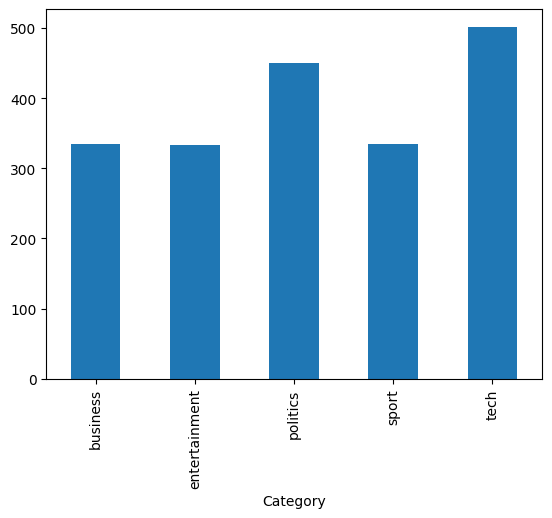

In [15]:
df.groupby("Category")["word_count"].mean().plot(kind="bar")
plt.show()

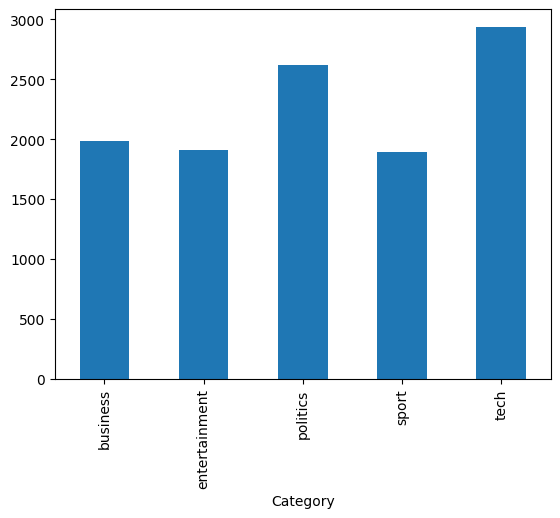

In [16]:
df.groupby("Category")["text_length"].mean().plot(kind="bar")
plt.show()

In [ ]:
# All categories are relatively balanced

#Text Representation

In [45]:
#preprosessing

texts = (
    df["Text"].fillna("").str.lower()
)

In [18]:
#vectorisation

vectorizer = CountVectorizer(
    stop_words = "english",
    max_df = 0.95,
    min_df = 5
)

X = vectorizer.fit_transform(texts)

In [19]:
X.shape

# Rows = BBC articles
# Columns = Vocabulary terms
# After filtering, the vocabulary contains 7115 terms

(1490, 7115)

In [20]:
feature_names = vectorizer.get_feature_names_out()

feature_names[:20]

array(['000', '000m', '05', '06', '10', '100', '100m', '101', '102',
       '104', '10bn', '10m', '10th', '11', '110', '111', '115', '11bn',
       '11th', '12'], dtype=object)

#LDA Topic Modeling


In [22]:
lda = LatentDirichletAllocation(
    n_components = 5,
    random_state = 42
)

lda.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

#Topic Interpretation

In [23]:
def show_topics(model, feature_names, n_words = 10):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        top_words = feature_names[top_indices]

        print(f"Topic {topic_idx}:")
        print(", ".join(top_words))
        print()

In [24]:
show_topics(lda, feature_names, n_words = 10)

Topic 0:
said, mr, labour, election, people, blair, party, new, government, brown

Topic 1:
said, game, england, time, win, year, players, ireland, half, wales

Topic 2:
said, people, mobile, technology, use, new, music, digital, users, software

Topic 3:
said, year, mr, government, new, market, uk, growth, firm, company

Topic 4:
film, best, said, year, won, mr, awards, director, star, award



In [25]:
df["Category"].value_counts()

,count
Category,
sport,346
business,336
politics,274
entertainment,273
tech,261


Topic 0:
said, mr, labour, election, people, blair, party, new, government, brown
- politics?

Topic 1:
said, game, england, time, win, year, players, ireland, half, wales
- sport

Topic 2:
said, people, mobile, technology, use, new, music, digital, users, software
- tech

Topic 3:
said, year, mr, government, new, market, uk, growth, firm, company
- business?

Topic 4:
film, best, said, year, won, mr, awards, director, star, award
- entertainment



#Document-Level Topic Distribution

In [26]:
document_topics = lda.transform(X)

In [27]:
document_topics.shape

(1490, 5)

In [28]:
document_topics[0]

array([0.00118387, 0.00117545, 0.0011856 , 0.2934615 , 0.70299358])

In [ ]:
# array([0.00118387, 0.00117545, 0.0011856 , 0.2934615 , 0.70299358])

# Predicted Topic 4(Entertainment) and Topic 3(Business)

In [46]:
texts.iloc[0]

# Seem to be Topic 3(Business)

'worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said andersen had given a  green light  to the procedures and practices used by worldcom. mr ebb

In [ ]:
#Each row of `document_topics` represents one article.

#Each value represents the estimated proportion of a latent topic in that article.

# Dominant Topic

In [30]:
dominant_topics = document_topics.argmax(axis=1)

In [ ]:
#argmax(axis = 1) returns the index of the largest topic probability for each document

In [31]:
df["Dominant_Topic"] = dominant_topics

In [32]:
df[["Category", "Dominant_Topic"]].head()

,Category,Dominant_Topic
0,business,4
1,business,3
2,business,3
3,tech,2
4,business,3


#Compare LDA Topics with BBC Categories

In [48]:
topic_category_table = pd.crosstab(
    df["Category"],
    df["Dominant_Topic"]
)

topic_category_table

Dominant_Topic,0,1,2,3,4
Category,,,,,
business,3,0,3,317,13
entertainment,71,0,4,5,193
politics,198,0,1,74,1
sport,1,283,10,1,51
tech,9,1,229,17,5


In [34]:
# Some entertainment articles have a dominant topic other than Topic 4.

#Topic Confidence

In [35]:
df["Topic_Confidence"] = document_topics.max(axis=1)

In [49]:
high_confidence = df.sort_values(
    "Topic_Confidence",
    ascending = False
    )[["Category", "Dominant_Topic", "Topic_Confidence", "Text"]]

high_confidence.head()

,Category,Dominant_Topic,Topic_Confidence,Text
1167,entertainment,4,0.998572,critics back aviator for oscars martin scorses...
1417,business,3,0.997854,the ticking budget facing the us the budget ...
1354,tech,2,0.997725,mobiles not media players yet mobiles are no...
343,tech,2,0.997725,mobiles not media players yet mobiles are no...
862,entertainment,4,0.997608,eastwood s baby scoops top oscars clint eastwo...


In [50]:
high_confidence.iloc[0]["Text"]

'critics back aviator for oscars martin scorsese s the aviator will win best film at the oscars  according to the uk s leading movie critics.  but several of those surveyed by the bbc news website think the veteran film-maker will lose the best director prize to clint eastwood. most of the critics tipped jamie foxx and hilary swank to scoop best actor and actress for ray and million dollar baby respectively. the jury comprised experts and critics from the top uk film publications. the panel also revealed which nominees they would personally prefer to win.  all expect the aviator to win best film  but many think it will be a close race between scorsese s howard hughes biopic and eastwood s boxing drama million dollar baby. the other films nominated are wine comedy sideways  factual drama finding neverland  and ray charles biopic ray.   i m pretty sure this is the year of the aviator  though my own choice would be sideways   said the observer s philip french.  sideways should win but it 

 'critics back aviator for oscars martin scorsese s the aviator will win best film at the oscars  according to the uk s leading movie critics.  but several of those surveyed by the bbc news website think the veteran film-maker will lose the best director prize to clint eastwood. most of the critics tipped jamie foxx and hilary swank to scoop best actor and actress for ray and million dollar baby respectively. the jury comprised experts and critics from the top uk film publications. the panel also revealed which nominees they would personally prefer to win.  all expect the aviator to win best film  but many think it will be a close race between scorsese s howard hughes biopic and eastwood s boxing drama million dollar baby. the other films nominated are wine comedy sideways  factual drama finding neverland  and ray charles biopic ray.   i m pretty sure this is the year of the aviator  though my own choice would be sideways   said the observer s philip french.  sideways should win but it d…<'

 - Oscars, critics, film, movie, director, prize, actor ...

#Ambiguous Articles

In [51]:
low_confidence = df.sort_values(
    "Topic_Confidence", ascending = True
)[
    ["Category", "Dominant_Topic", "Topic_Confidence", "Text"]
]

low_confidence.head()

,Category,Dominant_Topic,Topic_Confidence,Text
941,entertainment,4,0.261014,wal-mart is sued over rude lyrics the parents ...
665,entertainment,0,0.268431,singer knight backs anti-gun song r&b star bev...
555,entertainment,3,0.305213,rap boss arrested over drug find rap mogul mar...
990,tech,0,0.308523,portable playstation ready to go sony s playst...
498,tech,4,0.312754,bond game fails to shake or stir for gaming fa...


In [52]:
low_confidence.iloc[0]["Text"]

'wal-mart is sued over rude lyrics the parents of a 13-year-old girl are suing us supermarket giant wal-mart over a cd by rock group evanescence that contains swear words.  the lawsuit  filed in washington county  alleges wal-mart deceived customers by not putting warning labels on the cover. trevin skeens alleges wal-mart knew of the offending word because it had censored it on its music sales website. wal-mart said it was investigating the claims but had no plans to pull the cd. wal-mart has a policy of not stocking cds which carry parental advisory labels. mr skeens said he bought the anywhere but home cd for his daughter and was shocked to hear the swearing when it was played in their car.   i don t want any other families to get this  expecting it to be clean. it needs to be removed from the shelves to prevent other children from hearing it   said mr skeens of brownsville. the lawsuit seeks to force wal-mart to censor the music or remove it from its stores in maryland. it also see

wal-mart is sued over rude lyrics the parents of a 13-year-old girl are suing us supermarket giant wal-mart over a cd by rock group evanescence that contains swear words.  the lawsuit  filed in washington county  alleges wal-mart deceived customers by not putting warning labels on the cover. trevin skeens alleges wal-mart knew of the offending word because it had censored it on its music sales website. wal-mart said it was investigating the claims but had no plans to pull the cd. wal-mart has a policy of not stocking cds which carry parental advisory labels. mr skeens said he bought the anywhere but home cd for his daughter and was shocked to hear the swearing when it was played in their car.   i don t want any other families to get this  expecting it to be clean. it needs to be removed from the shelves to prevent other children from hearing it   said mr skeens of brownsville. the lawsuit seeks to force wal-mart to censor the music or remove it from its stores in maryland. it also seeks damages of up to $74 500 (£38 660) for every customer who bought the cd at maryland wal-marts  and also naming record label wind-up records and distributor bmg entertainment in the legal action.  while wal-mart sets high standards  it would not be possible to eliminate every image  word or topic that an individual might find objectionable   wal-mart spokesman guy whitcomb told the herald-mail of hagerstown.

- entertainment news but related to law suit and business(walmart)

#Number of Topics Experiment

In [54]:
for n_topics in [3, 5, 7, 10]:
    lda_test = LatentDirichletAllocation(
        n_components = n_topics,
        random_state = 42
    )

    lda_test.fit(X)

    print(f"\n---{n_topics} topics ---")
    show_topics(
        lda_test,
        feature_names,
        n_words = 8
    )


---3 topics ---
Topic 0:
said, mr, government, year, people, labour, new, election

Topic 1:
said, film, year, best, game, time, win, england

Topic 2:
said, people, new, mr, music, mobile, firm, year


---5 topics ---
Topic 0:
said, mr, labour, election, people, blair, party, new

Topic 1:
said, game, england, time, win, year, players, ireland

Topic 2:
said, people, mobile, technology, use, new, music, digital

Topic 3:
said, year, mr, government, new, market, uk, growth

Topic 4:
film, best, said, year, won, mr, awards, director


---7 topics ---
Topic 0:
mr, said, labour, election, blair, party, government, brown

Topic 1:
said, game, england, win, time, players, cup, ireland

Topic 2:
said, people, mobile, users, net, software, phone, use

Topic 3:
said, people, new, mr, government, uk, eu, digital

Topic 4:
film, best, said, awards, year, director, actor, films

Topic 5:
said, year, market, company, growth, firm, sales, 2004

Topic 6:
said, music, year, world, new, number, band,


---3 topics ---

Topic 0:
said, mr, government, year, people, labour, new, election
- politics

Topic 1:
said, film, year, best, game, time, win, england
- sports + entertainment

Topic 2:
said, people, new, mr, music, mobile, firm, year
- entertainment, tech, business?

---5 topics ---

Topic 0:
said, mr, labour, election, people, blair, party, new
- politics

Topic 1:
said, game, england, time, win, year, players, ireland
- sports

Topic 2:
said, people, mobile, technology, use, new, music, digital
- tech

Topic 3:
said, year, mr, government, new, market, uk, growth
- business

Topic 4:
film, best, said, year, won, mr, awards, director
- entertainment


---7 topics ---

Topic 0:
mr, said, labour, election, blair, party, government, brown
- politics

Topic 1:
said, game, england, win, time, players, cup, ireland
- sports

Topic 2:
said, people, mobile, users, net, software, phone, use
- tech

Topic 3:
said, people, new, mr, government, uk, eu, digital
- politics? tech?

Topic 4:
film, best, said, awards, year, director, actor, films
- entertainment(film-related)

Topic 5:
said, year, market, company, growth, firm, sales, 2004
- business(more accurate!)

Topic 6:
said, music, year, world, new, number, band, years
- entertainment(music-related)


---10 topics ---

Topic 0:
said, games, new, number, game, year, mr, book
- tech(game)

Topic 1:
said, game, players, club, england, cup, chelsea, time
- sports

Topic 2:
said, ireland, england, wales, game, france, virus, search
- sports(about teams?)

Topic 3:
said, new, uk, year, government, growth, mr, law
- politics

Topic 4:
mr, said, film, new, company, blogs, united, glazer
- entertainment(film?)

Topic 5:
said, year, firm, company, market, china, 2004, oil
- business

Topic 6:
said, year, world, band, time, best, won, new
- entertainment?(ambiguous)

Topic 7:
mr, said, labour, election, party, blair, government, people
- politics

Topic 8:
said, eu, world, economic, government, country, year, economy
- business, politics?

Topic 9:
said, people, film, music, best, mobile, tv, year
- entertainment, media?



In [ ]:
# With 7 topics, the model produced more fine-grained topics. For example, the entertainment category was divided into more specific themes, such as film-related and music-related topics.

# With 10 topics, however, the topic structure became less clear. Some topics combined terms from previously separate themes, making them more difficult to interpret consistently.

#Conclusion

The LDA model identified meaningful latent topics that broadly corresponded to the original BBC news categories without using the category labels during training.

Some articles showed lower topic confidence because they contained vocabulary from multiple domains, indicating that editorial categories do not always correspond perfectly to the underlying linguistic structure.

Increasing the number of topics to 7 produced more fine-grained themes, while 10 topics made several topics less distinct and harder to interpret. Overall, the project shows that topic modeling can reveal useful thematic structure, but the results depend on both the number of topics chosen and human interpretation.